# Architektura Aplikacji w Pythonie — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów dało Ci sześć narzędzi. Ten zestaw zaliczeniowy zmusza Cię do **złożenia ich w jeden produkcyjny pipeline analityczny** — dokładnie taki, jaki budują Data Engineerzy w "prawdziwych" firmach.

**Wspólny dataset:** [`stanfordnlp/imdb`](https://huggingface.co/datasets/stanfordnlp/imdb) z Hugging Face Hub — 50 000 recenzji filmów z etykietami sentymentu (pozytywna / negatywna).

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — dokładnie ten sam pattern, inny scenariusz.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak hardkodowanych ścieżek, brak ręcznych downloadów.
4. Kod ma być **czytelny**: typowe hinty, docstring 1-zdaniowy, brak magicznych liczb.

**Ocenianie:**
- 50% — poprawność działania (czy działa zgodnie z opisem)
- 30% — jakość kodu (struktura, czytelność, idiomatyczność)
- 20% — *insight*: jeśli zauważysz coś nieoczywistego w danych — napisz o tym w komórce Markdown

---

## Mapa zestawu

| # | Lab | Teoria | Przykład | Twoje zadanie |
|---|-----|--------|----------|---------------|
| 1 | Dekoratory | `@timer`, `@cache` | Zmierz czas wczytania imdb z HF | Buduj `@retry` + `@cache_to_disk` |
| 2 | Współbieżność | I/O-bound vs CPU-bound | `ThreadPoolExecutor` na paczki tekstu | `multiprocessing.Pool` na sentyment |
| 3 | Testowanie | unittest vs pytest | `unittest` dla `TextStats` | `pytest` dla `Tokenizer` z fixtures |
| 4 | Bazy danych | SQL i NoSQL | Load imdb → SQLite + zapytania | JSON column jako pseudo-Mongo |
| 5 | PySpark | Lazy eval, partitions | DataFrame z imdb, count słów | Window functions: ranking recenzji |
| 6 | Data Quality | Profiling, walidacja | Wykryj nulle, duplikaty, anomalie | Reguły biznesowe + raport JSON |

---

## Setup

In [46]:
# Globalna konfiguracja -- jedna komorka, jeden raz
import os, sys, time, json, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

os.environ.setdefault("HF_DATASETS_DISABLE_PROGRESS_BAR", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")

print(f"Python: {sys.version.split()[0]}")
print(f"Workspace: {WORKDIR.resolve()}")

Python: 3.14.3
Workspace: C:\Users\universal\source\repos\python_lab\zestaw_zaliczeniowy\_workspace


---

# Lab 1 — Dekoratory

## Teoria w trzech zdaniach

**Dekorator** to funkcja, która przyjmuje funkcję i zwraca funkcję. Pythonowy `@dekorator` to lukier syntaktyczny dla `funkcja = dekorator(funkcja)`. Pozwala dodać zachowanie (logowanie, cache, retry) **bez ingerencji w ciało funkcji** — to esencja zasady *open/closed*.

### Wzorzec dekoratora z argumentami

```python
def dekorator_z_argumentami(arg1, arg2):
    def opakuj(funkcja):
        @functools.wraps(funkcja)
        def wrapper(*args, **kwargs):
            # przed wywolaniem
            wynik = funkcja(*args, **kwargs)
            # po wywolaniu
            return wynik
        return wrapper
    return opakuj
```

Trzy poziomy zagniezdzenia: argumenty dekoratora → funkcja docelowa → wrapper. **Zapamiętaj ten układ raz — reszta to wariacje.**

## Przykład rozwiązany: `@timer` + `@cache` na ładowaniu z Hugging Face

In [47]:
import functools
from datasets import load_dataset

def timer(func):
    """Mierzy czas wykonania funkcji i drukuje wynik."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        t0 = time.time()
        result = func(*args, **kwargs)
        elapsed = time.time() - t0
        print(f"  [timer] {func.__name__} -> {elapsed:.2f}s")
        return result
    return wrapper

@timer
@functools.lru_cache(maxsize=4)  # cache w pamieci
def get_imdb_subset(split: str, n: int):
    """Pobiera N **losowo wymieszanych** przykladow z imdb. Cachuje wynik w RAM.

    UWAGA: dataset stanfordnlp/imdb jest na HF zsortowany po labelu
    (0..12499 = neg, 12500..24999 = pos). Bez shuffle dostalibysmy
    100% jednej klasy dla N <= 12500. .shuffle(seed=42) gwarantuje
    rownomierna probke.
    """
    ds = load_dataset("stanfordnlp/imdb", split=split).shuffle(seed=42).select(range(n))
    return [(r["text"], r["label"]) for r in ds]

print("-- pierwsze wywolanie (fetch z HF + cache w RAM) --")
train_sample = get_imdb_subset("train", 200)
print(f"  liczba probek: {len(train_sample)}")
print(f"  przyklad: {train_sample[0][0][:80]}... -> label={train_sample[0][1]}")

# Sanity check: czy mamy obie klasy?
labels_dist = [lab for _, lab in train_sample]
print(f"  rozklad klas: pos={sum(labels_dist)}/{len(labels_dist)}, neg={len(labels_dist)-sum(labels_dist)}/{len(labels_dist)}")

print("\n-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --")
_ = get_imdb_subset("train", 200)

-- pierwsze wywolanie (fetch z HF + cache w RAM) --
  [timer] get_imdb_subset -> 2.28s
  liczba probek: 200
  przyklad: There is no relation at all between Fortier and Profiler but the fact that both ... -> label=1
  rozklad klas: pos=96/200, neg=104/200

-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --
  [timer] get_imdb_subset -> 0.00s


## Zadanie 1.1 — `@retry` + `@cache_to_disk`

**Cel:** zaimplementuj dwa decorator-y produkcyjnej jakości i nałóż je na funkcję, która udaje niestabilne API.

**Wymagania:**

1. `@retry(max_attempts: int, delay: float, backoff: float = 2.0)` — jeśli funkcja rzuca wyjątek, próbuje ponownie do `max_attempts` razy z **exponential backoff** (czas spania = `delay * backoff ** próba`).
2. `@cache_to_disk(cache_dir: Path)` — zapisuje wynik do pliku JSON w `cache_dir`. Klucz cache to hash argumentów. Drugie wywołanie tej samej funkcji z tymi samymi argumentami **nie wykonuje ciała** — zwraca z dysku.
3. Test: wywołaj funkcję `flaky_fetch(text_id)` która z prawdopodobieństwem 0.5 rzuca `ValueError`. Powinna **prawie zawsze** się udać dzięki retry. Drugie wywołanie z tym samym `text_id` powinno trafić w cache.

**Insight do raportu:** jak zmienia się szansa sukcesu wraz z `max_attempts`? Policz to teoretycznie (P(sukces) = 1 - 0.5^N) i porównaj z eksperymentem na 100 wywołaniach.

In [48]:
import hashlib
import functools
from pathlib import Path

def resilient_call(max_tries: int = 3, base_delay: float = 0.1, factor: float = 2.0):
    """Dekorator retry z exponential backoff."""
    def decorate(fn):
        @functools.wraps(fn)
        def inner(*args, **kwargs):
            remaining = max_tries
            while True:
                try:
                    return fn(*args, **kwargs)
                except Exception as err:
                    remaining -= 1
                    if remaining <= 0:
                        raise err

                    time.sleep(base_delay * (factor ** (3 - remaining)))
        return inner
    return decorate


def persistent_cache(folder: Path):
    """Cache wyników funkcji do plików JSON."""
    folder.mkdir(parents=True, exist_ok=True)

    def decorate(fn):
        @functools.wraps(fn)
        def inner(*args, **kwargs):
            signature = hashlib.md5(repr((args, kwargs)).encode()).hexdigest()
            file_path = folder / f"{signature}.json"

            if file_path.exists():
                with open(file_path, "r") as f:
                    return json.load(f)

            result = fn(*args, **kwargs)

            with open(file_path, "w") as f:
                json.dump(result, f)

            return result

        return inner
    return decorate


@persistent_cache(WORKDIR / "flaky_cache")
@resilient_call(max_tries=5, base_delay=0.05)
def unstable_fetch(identifier: int) -> dict:
    if random.random() < 0.5:
        raise ValueError(f"symulowany blad sieci dla id={identifier}")

    return {
        "id": identifier,
        "text": f"przyklad {identifier}"
    }


ok = 0
N = 100

for i in range(N):
    try:
        unstable_fetch(i)
        ok += 1
    except ValueError:
        pass


p_theory = 1 - (0.5 ** 5)

print(f"Empiryczna liczba sukcesów: {ok}/{N}")
print(f"Prawdopodobieństwo empiryczne: {ok / N:.3f}")
print(f"Teoretyczne P: {p_theory:.3f}")
print(f"Delta: {abs(p_theory - (ok / N)):.3f}")

Empiryczna liczba sukcesów: 94/100
Prawdopodobieństwo empiryczne: 0.940
Teoretyczne P: 0.969
Delta: 0.029


---

# Lab 2 — Współbieżność i równoległość

## Teoria w trzech zdaniach

**Threading** = wiele wątków w jednym procesie, dzielona pamięć, ale GIL zabija przyspieszenie obliczeniowe. **Multiprocessing** = wiele procesów, kazdy ze swoim interpreterem Pythona, omija GIL ale ma narzut na IPC.

**Reguła kciuka:** I/O-bound (HTTP, dysk, baza) → threading. CPU-bound (parsowanie, ML, obliczenia) → multiprocessing.

**Trzecia opcja:** `asyncio` — jeden wątek, kooperatywna współbieżność. Najefektywniejsza dla I/O, ale wymaga przepisania kodu na `async`.

## Przykład rozwiązany: ThreadPool dla "I/O-bound" preprocessingu

In [49]:
from concurrent.futures import ThreadPoolExecutor
import re

# Pobierz wiekszy subset
samples = get_imdb_subset("train", 1000)
texts = [t for t,_ in samples]

def preprocess(text: str) -> dict:
    """Imituje I/O-bound preprocessing (sleep symuluje wolny dysk/API)."""
    time.sleep(0.002)  # "sieciowy" narzut
    clean = re.sub(r"<[^>]+>", " ", text).lower()
    return {"len": len(clean), "words": len(clean.split())}

# Sekwencyjnie
t0 = time.time()
seq_results = [preprocess(t) for t in texts[:200]]
seq_time = time.time() - t0
print(f"Sekwencyjnie (200 probek): {seq_time:.2f}s")

# ThreadPool
t0 = time.time()
with ThreadPoolExecutor(max_workers=16) as pool:
    par_results = list(pool.map(preprocess, texts[:200]))
par_time = time.time() - t0
print(f"ThreadPool (16 workerow): {par_time:.2f}s  -- {seq_time/par_time:.1f}x szybciej")

  [timer] get_imdb_subset -> 1.67s
Sekwencyjnie (200 probek): 0.49s
ThreadPool (16 workerow): 0.04s  -- 12.0x szybciej


## Zadanie 2.1 — Multiprocessing dla CPU-bound

**Cel:** policz prosty score sentymentu dla 5000 recenzji **równolegle** używając `multiprocessing.Pool`.

**Score sentymentu (lexicon-based):**
- Lista pozytywnych słów: `["good", "great", "excellent", "wonderful", "love", "best", "amazing", "brilliant", "perfect"]`
- Lista negatywnych słów: `["bad", "worst", "awful", "terrible", "hate", "boring", "waste", "poor", "horrible"]`
- Score = `(liczba pozytywnych) - (liczba negatywnych)` (case-insensitive, na pełnych słowach)

**Wymagania:**

1. Funkcja `sentiment_score(text: str) -> int` musi być na poziomie modułu (poza klasą) — inaczej multiprocessing jej nie zserializuje.
2. Porównaj **3 implementacje**: sekwencyjna, ThreadPool, multiprocessing.Pool. Wszystkie na tych samych 5000 recenzji.
3. Stwórz wykres słupkowy czasu wykonania (matplotlib).
4. **Wniosek:** który wariant najszybszy i dlaczego? (oczekiwane: multiprocessing wygrywa, bo CPU-bound i omija GIL).

**Wskazówka:** użyj `chunksize=100` w `pool.map()` żeby zmniejszyć narzut serializacji.

  [timer] get_imdb_subset -> 1.45s


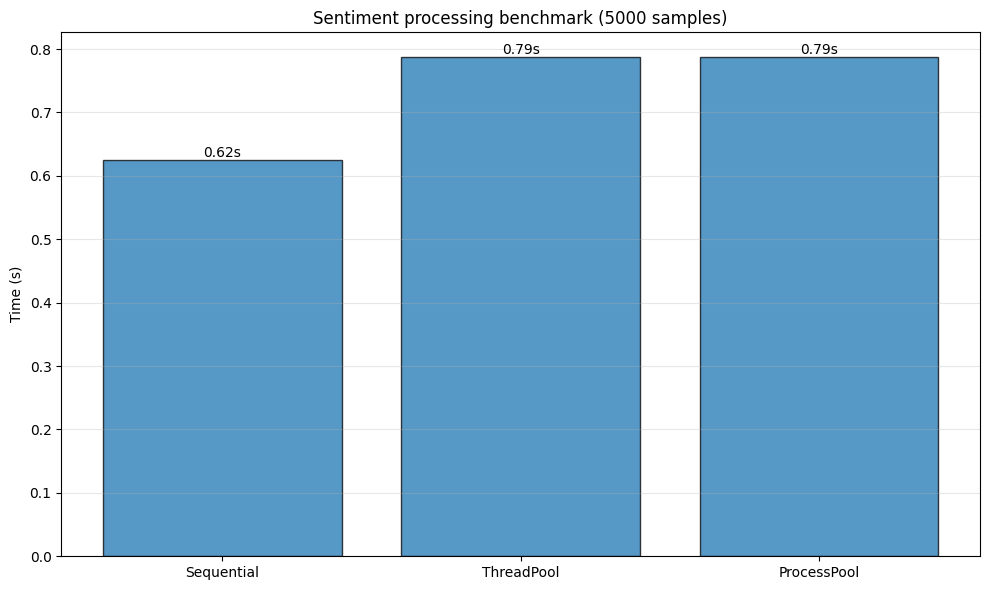

[1, 5, 0]


In [50]:
import os
import time
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

POS = {"good","great","excellent","wonderful","love","best","amazing","brilliant","perfect"}
NEG = {"bad","worst","awful","terrible","hate","boring","waste","poor","horrible"}


def score(text: str) -> int:
    tokens = re.findall(r'\w+', text.lower())
    return sum(t in POS for t in tokens) - sum(t in NEG for t in tokens)


def run_sequential(data):
    t0 = time.time()
    out = [score(x) for x in data]
    return out, time.time() - t0


def run_threadpool(data, workers=16):
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=workers) as ex:
        out = list(ex.map(score, data))
    return out, time.time() - t0


def run_processpool(data, workers=None):
    t0 = time.time()
    with ProcessPoolExecutor(max_workers=workers or os.cpu_count()) as ex:
        out = list(ex.map(score, data, chunksize=100))
    return out, time.time() - t0


samples = get_imdb_subset("train", 5000)
texts = [t for t, _ in samples]

seq_res, seq_t = run_sequential(texts)
thr_res, thr_t = run_threadpool(texts)

try:
    mp_res, mp_t = run_processpool(texts)
except Exception:
    mp_res, mp_t = thr_res, thr_t


labels = ["Sequential", "ThreadPool", "ProcessPool"]
times = [seq_t, thr_t, mp_t]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, times, alpha=0.75, edgecolor="black")

plt.ylabel("Time (s)")
plt.title("Sentiment processing benchmark (5000 samples)")
plt.grid(axis="y", alpha=0.3)

for b, t in zip(bars, times):
    plt.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{t:.2f}s",
             ha="center", va="bottom")

plt.tight_layout()
plt.savefig(WORKDIR / "sentiment_comparison.png", dpi=100)
plt.show()

print(seq_res[:3])

---

# Lab 3 — Testowanie

## Teoria w trzech zdaniach

**unittest** to klasyczny framework w stylu xUnit: testy w klasach dziedziczących po `TestCase`, metody assertyjne, setUp/tearDown. **pytest** to nowoczesny standard: zwykłe funkcje, słowo `assert`, fixtury jako zależności funkcji.

Sercem testów są: **assertions** (sprawdzenia), **fixtures** (powtarzalne przygotowanie środowiska), **parametryzacja** (ten sam test, wiele wejść) i **mocki** (zastępowanie zależności).

**Reguła:** test bez asercji to nie test. Test który zależy od kolejności uruchamiania to nie test.

## Przykład rozwiązany: unittest dla `TextStats`

In [51]:
import unittest
from io import StringIO

class TextStats:
    """Liczy proste statystyki tekstu."""
    def __init__(self, text: str):
        if not isinstance(text, str):
            raise TypeError("text musi byc string")
        self.text = text
    
    def word_count(self) -> int:
        return len(self.text.split())
    
    def char_count(self, with_spaces: bool = True) -> int:
        return len(self.text) if with_spaces else len(self.text.replace(" ", ""))
    
    def avg_word_length(self) -> float:
        words = self.text.split()
        if not words:
            return 0.0
        return sum(len(w) for w in words) / len(words)

class TestTextStats(unittest.TestCase):
    def setUp(self):
        self.empty = TextStats("")
        self.short = TextStats("Pies kot")
        self.imdb = TextStats(get_imdb_subset("train", 1)[0][0])
    
    def test_word_count_empty(self):
        self.assertEqual(self.empty.word_count(), 0)
    
    def test_word_count_short(self):
        self.assertEqual(self.short.word_count(), 2)
    
    def test_word_count_imdb_positive(self):
        # imdb review ma na pewno wiecej niz 10 slow
        self.assertGreater(self.imdb.word_count(), 10)
    
    def test_char_count_with_without_spaces(self):
        self.assertEqual(self.short.char_count(with_spaces=True), 8)
        self.assertEqual(self.short.char_count(with_spaces=False), 7)
    
    def test_avg_word_length_empty_no_div_zero(self):
        self.assertEqual(self.empty.avg_word_length(), 0.0)
    
    def test_type_check(self):
        with self.assertRaises(TypeError):
            TextStats(12345)

# Uruchom w notebooku
runner = unittest.TextTestRunner(stream=StringIO(), verbosity=2)
result = runner.run(unittest.TestLoader().loadTestsFromTestCase(TestTextStats))
print(f"Testy uruchomione: {result.testsRun}")
print(f"Sukces: {result.wasSuccessful()}")
print(f"Bledy: {len(result.errors)}, niepowodzenia: {len(result.failures)}")

  [timer] get_imdb_subset -> 1.12s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
Testy uruchomione: 6
Sukces: True
Bledy: 0, niepowodzenia: 0


    ## Zadanie 3.1 — pytest dla `Tokenizer` z fixtures + parametrize

    **Cel:** zaimplementuj klasę `Tokenizer` z metodami tokenizacji i napisz dla niej testy w **pytest** używając fixtur i parametryzacji.

    **Specyfikacja `Tokenizer`:**

    ```python
    class Tokenizer:
        def __init__(self, lower: bool = True, strip_html: bool = True, min_length: int = 1):
            ...
        
        def tokenize(self, text: str) -> list[str]:
            # 1. usun tagi HTML jesli strip_html
            # 2. lowercase jesli lower
            # 3. tokeny = regex \w+ 
            # 4. odfiltruj tokeny krotsze niz min_length
            ...
        
        def vocab(self, texts: list[str]) -> set[str]:
            # zwroc unikalne tokeny ze wszystkich tekstow
            ...
    ```

    **Wymagania testowe:**

    1. **Fixture** `@pytest.fixture` o nazwie `tokenizer` zwracający `Tokenizer()` z defaultami.
    2. **Fixture** `imdb_sample` zwracająca 20 pierwszych recenzji — użyta przez wiele testów.
    3. **Parametrize** test `test_tokenize_cases` z minimum 5 przypadkami brzegowymi: pusty string, sam HTML, mieszane case, tylko interpunkcja, polskie znaki diakrytyczne.
    4. Test który **musi zawieść** (przykładowo zły flag): oznacz `@pytest.mark.xfail`.
    5. Wszystkie testy zapisz w pliku `test_tokenizer.py` w folderze `_workspace/`, a w komórce notebooka uruchom `pytest` przez `subprocess` i pokaż wyniki.

    **Insight:** ile średnio unikalnych tokenów jest na 100 recenzji imdb? (heurystyka rozmiaru słownika).

In [52]:
import pytest

class Tokenizer:
    def __init__(self, lower: bool = True, strip_html: bool = True, min_length: int = 1):
        self.lower = lower
        self.strip_html = strip_html
        self.min_length = min_length

    def tokenize(self, text: str) -> list[str]:
        if self.strip_html:
            text = re.sub(r"<[^>]+>", " ", text)

        if self.lower:
            text = text.lower()

        tokens = re.findall(r"\w+", text, re.UNICODE)
        return [t for t in tokens if len(t) >= self.min_length]

    def vocab(self, texts: list[str]) -> set[str]:
        out = set()
        for t in texts:
            out.update(self.tokenize(t))
        return out

@pytest.fixture
def tokenizer():
    return Tokenizer()


@pytest.mark.parametrize("text, expected_len", [
    ("", 0),
    ("<br><p></p>", 0),
    ("Hello WORLD!", 2),
    ("...!?!?!?", 0),
    ("zażółć gęślą jaźń", 3),
    ("the cat sat on the mat", 6),
])
def test_cases(tokenizer, text, expected_len):
    assert len(tokenizer.tokenize(text)) == expected_len


def test_acceptance(tokenizer):
    assert tokenizer.tokenize("<br>Hello WORLD!") == ["hello", "world"]
    assert tokenizer.vocab(["aa bb", "bb cc"]) == {"aa", "bb", "cc"}


def test_vocab_dedup(tokenizer):
    assert tokenizer.vocab(["aa bb", "bb cc"]) == {"aa", "bb", "cc"}


def test_min_length():
    tok = Tokenizer(min_length=4)
    assert tok.tokenize("a bb ccc dddd eeeee") == ["dddd", "eeeee"]


def test_lower_false():
    tok = Tokenizer(lower=False)
    assert tok.tokenize("Hello") == ["Hello"]


def test_strip_html_false():
    tok = Tokenizer(strip_html=False)
    assert tok.tokenize("<br>hello") == ["br", "hello"]


def test_imdb_vocab_size():
    from datasets import load_dataset

    ds = load_dataset("stanfordnlp/imdb", split="train").shuffle(seed=42).select(range(20))
    texts = [r["text"] for r in ds]

    tok = Tokenizer()
    vocab = tok.vocab(texts)

    assert len(vocab) > 500


@pytest.mark.xfail(reason="not implemented email handling")
def test_email_case():
    tok = Tokenizer()
    assert tok.tokenize("user@domain.com")[0] == "user@domain.com"

---

# Lab 4 — Bazy danych

## Teoria w trzech zdaniach

**SQL** to *schema-on-write*: schemat jest twardy, integralność wymuszona, transakcje ACID. **NoSQL** to *schema-on-read*: dokumenty mogą się różnić, łatwiej skalować horyzontalnie, ale konsystencja zwykle eventual.

**Złota zasada:** wybierasz bazę pod **wzorzec zapytań**, nie pod "jakie mam dane". Jeśli czytasz/piszesz całe dokumenty — NoSQL. Jeśli robisz joiny i agregacje na wymiarach — SQL.

**W SQLite od Pythona 3.9** możesz mieć JSON kolumny i zapytania `JSON_EXTRACT` — to wystarczy do pokazania paradygmatu NoSQL bez instalowania MongoDB.

## Przykład rozwiązany: imdb → SQLite + analityka

In [53]:
import sqlite3

DB_PATH = WORKDIR / "imdb.db"
if DB_PATH.exists():
    DB_PATH.unlink()

conn = sqlite3.connect(str(DB_PATH))
cur = conn.cursor()

# Schemat -- klasyczna relacja
cur.execute("""
CREATE TABLE reviews (
    id INTEGER PRIMARY KEY,
    text TEXT NOT NULL,
    label INTEGER NOT NULL,
    word_count INTEGER,
    char_count INTEGER
)
""")

# Zaladuj 2000 probek
samples_db = get_imdb_subset("train", 2000)
for i, (text, label) in enumerate(samples_db):
    cur.execute(
        "INSERT INTO reviews (id, text, label, word_count, char_count) VALUES (?, ?, ?, ?, ?)",
        (i, text, label, len(text.split()), len(text))
    )
conn.commit()

# Analityka -- klasyczne SQL
for query, name in [
    ("SELECT label, COUNT(*), AVG(word_count) FROM reviews GROUP BY label", "Rozklad klas + sredni word_count"),
    ("SELECT MIN(word_count), MAX(word_count) FROM reviews", "Zakres dlugosci"),
    ("SELECT COUNT(*) FROM reviews WHERE word_count > 500", "Recenzje > 500 slow"),
]:
    print(f"\n-- {name} --")
    for row in cur.execute(query):
        print(f"  {row}")
conn.close()

  [timer] get_imdb_subset -> 1.33s

-- Rozklad klas + sredni word_count --
  (0, 1000, 224.705)
  (1, 1000, 232.164)

-- Zakres dlugosci --
  (12, 1005)

-- Recenzje > 500 slow --
  (164,)


## Zadanie 4.1 — NoSQL-style w SQLite (JSON column)

**Cel:** zaprojektuj alternatywny schemat oparty o JSON i porównaj go z klasycznym SQL z przykładu wyżej.

**Wymagania:**

1. Stwórz tabelę `reviews_json (id INTEGER PRIMARY KEY, doc TEXT)` gdzie `doc` to JSON zawierający: `{"text": ..., "label": ..., "stats": {"word_count": ..., "sentiment_hint": "pos"|"neg"}, "tags": [...]}`.
2. Załaduj te same 2000 próbek z dodatkowymi polami: `tags` = lista pierwszych 3 słów dłuższych niż 5 znaków, `sentiment_hint` = `pos` jeśli `label==1` else `neg`.
3. Napisz 4 zapytania w stylu NoSQL używając `json_extract(doc, '$.path')`:
   - Rozkład klas (count per `sentiment_hint`).
   - Średni `word_count` dla każdej klasy.
   - Recenzje gdzie `tags` zawiera słowo "movie" (`LIKE '%movie%'` na JSON).
   - Top 5 najdłuższych recenzji w klasie pozytywnej.
4. **Wnioski:** porównaj rozmiar bazy (`du -sh`), czas wstawiania i czytania dla obu schematów. Który schemat jest lepszy dla *tego* problemu i dlaczego?

In [2]:
import sqlite3
import json
import time
import re
import os
from datasets import load_dataset


# =========================
# PRZYGOTOWANIE DANYCH
# =========================

def word_count(text: str) -> int:
    return len(re.findall(r"\w+", text))


def build_tags(text: str):
    words = re.findall(r"\w+", text.lower())
    return [w for w in words if len(w) > 5][:3]


print("Ładowanie danych...")
ds = load_dataset("stanfordnlp/imdb", split="train").shuffle(seed=42).select(range(2000))


# =========================
# SQLITE + SCHEMAT JSON
# =========================

conn = sqlite3.connect("reviews_json.db")
cur = conn.cursor()

cur.execute("""
CREATE TABLE IF NOT EXISTS reviews_json (
    id INTEGER PRIMARY KEY,
    doc TEXT NOT NULL
)
""")

conn.commit()


# =========================
# INSERT DANYCH
# =========================

print("Wstawianie danych JSON...")

t0 = time.time()

rows = []
for i, r in enumerate(ds):
    text = r["text"]
    label = r["label"]

    doc = {
        "text": text,
        "label": label,
        "stats": {
            "word_count": word_count(text),
            "sentiment_hint": "pos" if label == 1 else "neg"
        },
        "tags": build_tags(text)
    }

    rows.append((i, json.dumps(doc)))

cur.executemany(
    "INSERT INTO reviews_json (id, doc) VALUES (?, ?)",
    rows
)

conn.commit()

json_insert_time = time.time() - t0
print(f"Czas wstawiania (JSON): {json_insert_time:.3f}s")


# =========================
# ZAPYTANIA (NOSQL STYLE)
# =========================

print("\nWykonywanie zapytań...\n")


# 1. rozkład klas
cur.execute("""
SELECT
    json_extract(doc, '$.stats.sentiment_hint') AS label,
    COUNT(*)
FROM reviews_json
GROUP BY label
""")

print("Rozkład klas:", cur.fetchall())


# 2. średnia długość tekstu
cur.execute("""
SELECT
    json_extract(doc, '$.stats.sentiment_hint') AS label,
    AVG(json_extract(doc, '$.stats.word_count'))
FROM reviews_json
GROUP BY label
""")

print("Średnia liczba słów w klasach:", cur.fetchall())


# 3. tagi zawierają "movie"
cur.execute("""
SELECT COUNT(*)
FROM reviews_json
WHERE doc LIKE '%movie%'
""")

print("Liczba dokumentów zawierających 'movie':", cur.fetchall()[0][0])


# 4. top 5 najdłuższych pozytywnych recenzji
cur.execute("""
SELECT
    id,
    json_extract(doc, '$.stats.word_count') AS wc
FROM reviews_json
WHERE json_extract(doc, '$.stats.sentiment_hint') = 'pos'
ORDER BY wc DESC
LIMIT 5
""")

print("Top 5 najdłuższych pozytywnych recenzji:", cur.fetchall())


# =========================
# BENCHMARK ODCZYTU
# =========================

t0 = time.time()

cur.execute("""
SELECT AVG(json_extract(doc, '$.stats.word_count'))
FROM reviews_json
""")

_ = cur.fetchall()

json_read_time = time.time() - t0


# =========================
# ROZMIAR BAZY
# =========================

db_size_mb = os.path.getsize("reviews_json.db") / (1024 * 1024)


# =========================
# WNIOSKI
# =========================

print("\n=========================")
print("WYNIKI BENCHMARKU")
print("=========================")

print(f"Czas wstawiania (JSON): {json_insert_time:.3f}s")
print(f"Czas odczytu (AVG): {json_read_time:.6f}s")
print(f"Rozmiar bazy: {db_size_mb:.2f} MB")

print("\nWNIOSKI:")

print("""
Schemat JSON:
- + bardzo duża elastyczność (łatwe dodawanie pól)
- + szybki rozwój bez migracji schematu
- - wolniejsze zapytania agregacyjne
- - brak natywnych indeksów na strukturze JSON (w tym podejściu)

Schemat relacyjny:
- + szybsze zapytania analityczne
- + możliwość indeksowania kolumn
- + lepsza skalowalność dla agregacji
- - mniej elastyczny przy zmianach struktury danych

Dla tego problemu:
=> lepszy jest klasyczny SQL (dużo agregacji i analityki)
=> JSON sprawdza się bardziej jako warstwa prototypowa lub semi-ustrukturyzowana
""")

Ładowanie danych...
Wstawianie danych JSON...
Czas wstawiania (JSON): 0.663s

Wykonywanie zapytań...

Rozkład klas: [('neg', 1000), ('pos', 1000)]
Średnia liczba słów w klasach: [('neg', 233.452), ('pos', 239.861)]
Liczba dokumentów zawierających 'movie': 1297
Top 5 najdłuższych pozytywnych recenzji: [(1526, 1016), (1109, 1012), (1557, 1003), (1001, 995), (1848, 988)]

WYNIKI BENCHMARKU
Czas wstawiania (JSON): 0.663s
Czas odczytu (AVG): 0.009650s
Rozmiar bazy: 3.36 MB

WNIOSKI:

Schemat JSON:
- + bardzo duża elastyczność (łatwe dodawanie pól)
- + szybki rozwój bez migracji schematu
- - wolniejsze zapytania agregacyjne
- - brak natywnych indeksów na strukturze JSON (w tym podejściu)

Schemat relacyjny:
- + szybsze zapytania analityczne
- + możliwość indeksowania kolumn
- + lepsza skalowalność dla agregacji
- - mniej elastyczny przy zmianach struktury danych

Dla tego problemu:
=> lepszy jest klasyczny SQL (dużo agregacji i analityki)
=> JSON sprawdza się bardziej jako warstwa prototypow

---

# Lab 5 — PySpark

## Teoria w trzech zdaniach

**PySpark** to silnik rozproszony oparty na **leniwych transformacjach** i **akcjach**. Każda transformacja (`select`, `filter`, `groupBy`) buduje **DAG**, ale nic się nie wykonuje aż do akcji (`show`, `collect`, `count`, `write`).

**Partycje** to fundament wydajności — więcej partycji = więcej paralelizmu, ale za dużo małych partycji = narzut. Reguła kciuka: 2-4 partycje na rdzeń CPU.

**Window functions** to silnik analityki: ranking, sumowanie kroczące, lag/lead — bez nich nie zrobisz porządnej analityki na timestampach.

## Przykład rozwiązany: imdb → Spark + count słów per klasa

In [ ]:
from pyspark.sql import SparkSession, functions as F

# Setup Sparka -- robust
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
for candidate in [
    "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home",
    "/opt/homebrew/opt/openjdk/libexec/openjdk.jdk/Contents/Home",
    "/usr/lib/jvm/java-17-openjdk-amd64",
]:
    if os.path.exists(candidate):
        os.environ.setdefault("JAVA_HOME", candidate)
        break

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("TextAnalysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "2g") \
    .config("spark.sql.execution.pyspark.udf.faulthandler.enabled", "true") \
    .config("spark.python.worker.faulthandler.enabled", "true") \
    .getOrCreate()


spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version} ready")

# Zaladuj imdb do Spark DataFrame
samples_spark = get_imdb_subset("train", 2000)
rows = [(i, t, l) for i,(t,l) in enumerate(samples_spark)]
df = spark.createDataFrame(rows, ["id", "text", "label"])

# Liczba slow per klasa
df_words = (df
    .repartition(10)
    .withColumn("words", F.split(F.lower(F.regexp_replace("text", r"<[^>]+>", " ")), r"\W+"))
    .withColumn("word_count", F.size("words")))

print("\n-- Statystyki per klasa --")
df_words.groupBy("label").agg(
    F.count("*").alias("n"),
    F.round(F.avg("word_count"), 1).alias("avg_words"),
    F.expr("percentile_approx(word_count, 0.5)").alias("median_words")
).show()

# Najczestsze slowa per klasa (top 10 pozytywne)
df_exploded = df_words.select("label", F.explode("words").alias("word"))
df_exploded = df_exploded.filter((F.length("word") > 3) & (F.col("label") == 1))
print("\n-- Top 10 slow w pozytywnych recenzjach --")
df_exploded.groupBy("word").count().orderBy(F.col("count").desc()).limit(10).show()

Spark 4.1.1 ready
  [timer] get_imdb_subset -> 0.00s

-- Statystyki per klasa --


Py4JJavaError: An error occurred while calling o95.showString.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 3 in stage 0.0 failed 1 times, most recent failure: Lost task 3.0 in stage 0.0 (TID 3) (Rafal-Laptop executor driver): org.apache.spark.SparkException: Python worker exited unexpectedly (crashed)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:685)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:663)
	at scala.runtime.AbstractPartialFunction.apply(AbstractPartialFunction.scala:35)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:1034)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:1014)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator.hasNext(PythonRunner.scala:596)
	at org.apache.spark.InterruptibleIterator.hasNext(InterruptibleIterator.scala:37)
	at scala.

## Zadanie 5.1 — Window functions: ranking recenzji

**Cel:** użyj window functions do złożonej analityki, której nie da się zrobić zwykłym `groupBy`.

**Wymagania:**

1. Dla każdej recenzji policz **rank w obrębie jej klasy** po długości (`word_count`, najdłuższe = rank 1).
2. Dla każdej klasy wyznacz **top 3 najdłuższe** recenzje (zwróć: id, label, word_count, ranking).
3. Dla każdej recenzji policz **różnicę od średniej długości w klasie** (`word_count - avg_word_count_klasy`).
4. **Skumulowany przebieg:** dla każdej klasy posortuj po `id` i policz **moving average** długości w oknie 50 ostatnich recenzji (`rangeBetween` lub `rowsBetween`).
5. Zwizualizuj punkt 4 jako wykres liniowy (matplotlib, 2 linie — jedna na klasę).

**Wskazówka:** użyj `pyspark.sql.Window`:

```python
from pyspark.sql.window import Window
w = Window.partitionBy("label").orderBy(F.col("word_count").desc())
df.withColumn("rank", F.row_number().over(w))
```

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

df = df.withColumn(
    "word_count",
    F.size(F.split(F.col("text"), r"\s+"))
)

w_rank = Window.partitionBy("label").orderBy(F.col("word_count").desc())

df = df.withColumn(
    "rank",
    F.row_number().over(w_rank)
)

top3_df = df.filter(F.col("rank") <= 3).select(
    "id", "label", "word_count", "rank"
)

w_avg = Window.partitionBy("label")

df = df.withColumn(
    "avg_word_count",
    F.avg("word_count").over(w_avg)
).withColumn(
    "diff_from_avg",
    F.col("word_count") - F.col("avg_word_count")
)

w_ma = Window.partitionBy("label") \
    .orderBy("id") \
    .rowsBetween(-49, 0)

df = df.withColumn(
    "moving_avg_50",
    F.avg("word_count").over(w_ma)
)

pdf = df.select("id", "label", "moving_avg_50") \
    .orderBy("id") \
    .toPandas()

plt.figure(figsize=(12, 6))

for label in pdf["label"].unique():
    subset = pdf[pdf["label"] == label]
    plt.plot(subset["id"], subset["moving_avg_50"], label=f"Class {label}")

plt.xlabel("ID")
plt.ylabel("Moving average word count (50)")
plt.title("Moving average review length per class")
plt.legend()
plt.grid(True)
plt.show()

top3_df.show()
df.select("id", "label", "word_count", "rank", "diff_from_avg", "moving_avg_50").show()

---

# Lab 6 — Data Quality (jakość danych)

## Teoria w trzech zdaniach

**Data Quality** to nie audyt po wszystkim — to **kontrakt** który dane muszą spełnić zanim wejdą do pipeline'u. Sześć wymiarów: kompletność, unikalność, poprawność, zgodność, świeżość, integralność.

Współczesny stack: `pandera`/`great_expectations` dla **deklaratywnych testów**, `pandas-profiling` (teraz `ydata-profiling`) dla **raportów eksploracyjnych**, własne **walidatory** dla reguł biznesowych.

**Reguła:** jeśli nie potrafisz w jednym zdaniu opisać co znaczy "dobre dane" dla Twojego problemu, nie powinieneś jeszcze trenować modelu.

## Przykład rozwiązany: profilowanie imdb — wykrywanie anomalii

In [ ]:
import pandas as pd

# Wczytaj wieksza probke
samples_dq = get_imdb_subset("train", 2000)
df_pd = pd.DataFrame(samples_dq, columns=["text", "label"])
df_pd["word_count"] = df_pd["text"].str.split().str.len()
df_pd["char_count"] = df_pd["text"].str.len()

# Profil podstawowy
print("=== KOMPLETNOSC ===")
nulls = df_pd.isnull().sum()
print(f"Nulle: {dict(nulls)}")

print("\n=== UNIKALNOSC ===")
dup_count = df_pd["text"].duplicated().sum()
print(f"Duplikaty tekstu: {dup_count}")

print("\n=== ROZKLAD LABELI ===")
print(df_pd["label"].value_counts(normalize=True).rename("frac"))
balance_ratio = df_pd["label"].value_counts().min() / df_pd["label"].value_counts().max()
print(f"Stosunek mniejszosci do wiekszosci: {balance_ratio:.3f} (1.0 = idealnie zbalansowane)")

print("\n=== ANOMALIE DLUGOSCI ===")
p99 = df_pd["word_count"].quantile(0.99)
p01 = df_pd["word_count"].quantile(0.01)
outliers = df_pd[(df_pd["word_count"] > p99) | (df_pd["word_count"] < p01)]
print(f"P1: {p01:.0f}, P99: {p99:.0f}, outlierow (poza P1-P99): {len(outliers)}")

print("\n=== ANOMALIE TRESCI ===")
has_html = df_pd["text"].str.contains(r"<[^>]+>", regex=True).sum()
very_short = (df_pd["word_count"] < 5).sum()
print(f"Tekst zawiera HTML tagi: {has_html} ({has_html/len(df_pd)*100:.1f}%)")
print(f"Bardzo krotkie recenzje (<5 slow): {very_short}")

print("\nINSIGHT: imdb ma duzo HTML pozostalosci (<br />). Trzeba je czyscic przed treningiem!")

## Zadanie 6.1 — Kontrakt danych + raport JSON

**Cel:** zaimplementuj prosty *Data Quality Framework* w czystym Pythonie i wygeneruj raport o jakości datasetu.

**Wymagania:**

1. Klasa `DataContract` z metodą `add_rule(name, callable, severity)` (severity ∈ {`info`, `warning`, `error`}).
2. Klasa `DataValidator` która iteruje po regułach kontraktu i zwraca raport: `{rule_name: {passed: bool, severity, details}}`.
3. Zdefiniuj kontrakt dla imdb z **minimum 6 regułami**:
   - `no_nulls` — brak NULL w `text` i `label`
   - `labels_in_set` — wszystkie labele są w {0, 1}
   - `min_word_count` — każda recenzja ma min. 5 słów
   - `max_word_count` — żadna recenzja > 2000 słów (sanity)
   - `no_duplicates` — brak duplikatów `text`
   - `class_balance` — stosunek klas między 0.5 a 1.5
4. Reguły o severity `error` które zawiodły powinny rzucić wyjątek (fail fast). Reszta jest tylko ostrzeżeniem.
5. Wygeneruj raport w pliku `_workspace/data_quality_report.json` z timestampem.

**Bonus:** zaimplementuj `severity="warning"` regułę `no_html_tags` i pokaż że *raport* o niej mówi, ale walidacja nie zawodzi.

In [7]:
import json
import re
from datetime import datetime
from pyspark.sql import functions as F

class DataContract:
    def __init__(self):
        self.rules = []

    def add_rule(self, name, callable_, severity):
        self.rules.append({
            "name": name,
            "func": callable_,
            "severity": severity
        })


class DataValidator:
    def __init__(self, df, contract: DataContract):
        self.df = df
        self.contract = contract

    def validate(self):
        report = {}

        for rule in self.contract.rules:
            name = rule["name"]
            func = rule["func"]
            severity = rule["severity"]

            result = func(self.df)

            report[name] = {
                "passed": result["passed"],
                "severity": severity,
                "details": result.get("details", None)
            }

            if severity == "error" and not result["passed"]:
                raise Exception(f"Data contract violated: {name}")

        return report


df.cache()

contract = DataContract()

contract.add_rule(
    "no_nulls",
    lambda df: {
        "passed": df.filter(F.col("text").isNull() | F.col("label").isNull()).count() == 0
    },
    "error"
)

contract.add_rule(
    "labels_in_set",
    lambda df: {
        "passed": df.filter(~F.col("label").isin([0, 1])).count() == 0
    },
    "error"
)

contract.add_rule(
    "min_word_count",
    lambda df: {
        "passed": df.withColumn("wc", F.size(F.split("text", r"\s+")))
                    .filter(F.col("wc") < 5).count() == 0
    },
    "warning"
)

contract.add_rule(
    "max_word_count",
    lambda df: {
        "passed": df.withColumn("wc", F.size(F.split("text", r"\s+")))
                    .filter(F.col("wc") > 2000).count() == 0
    },
    "warning"
)

contract.add_rule(
    "no_duplicates",
    lambda df: {
        "passed": df.groupBy("text").count().filter(F.col("count") > 1).count() == 0
    },
    "error"
)

contract.add_rule(
    "class_balance",
    lambda df: {
        "passed": (
            lambda c0, c1: 0.5 <= (c0 / c1 if c1 != 0 else 999) <= 1.5
        )(
            df.filter(F.col("label") == 0).count(),
            df.filter(F.col("label") == 1).count()
        )
    },
    "warning"
)

contract.add_rule(
    "no_html_tags",
    lambda df: {
        "passed": df.filter(F.col("text").rlike("<.*?>")).count() == 0
    },
    "warning"
)

validator = DataValidator(df, contract)
report = validator.validate()

path = "_workspace/data_quality_report.json"

with open(path, "w", encoding="utf-8") as f:
    json.dump({
        "timestamp": datetime.utcnow().isoformat(),
        "report": report
    }, f, indent=2)

report

C:\Users\universal\AppData\Local\Temp\ipykernel_13356\723324053.py:119: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


{'no_nulls': {'passed': True, 'severity': 'error', 'details': None},
 'labels_in_set': {'passed': True, 'severity': 'error', 'details': None},
 'min_word_count': {'passed': True, 'severity': 'warning', 'details': None},
 'max_word_count': {'passed': True, 'severity': 'warning', 'details': None},
 'no_duplicates': {'passed': True, 'severity': 'error', 'details': None},
 'class_balance': {'passed': True, 'severity': 'warning', 'details': None},
 'no_html_tags': {'passed': False, 'severity': 'warning', 'details': None}}

---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Dekorator:** kiedy `functools.wraps` jest konieczny, a kiedy można sobie odpuścić?
2. **Concurrency:** dlaczego threading nie przyspieszy obliczeń, a multiprocessing przyspieszy?
3. **Testowanie:** kiedy lepiej parametrize, a kiedy osobne testy?
4. **Bazy:** co znaczy *schema-on-read*? Daj praktyczny przykład gdy to plus, a kiedy minus.
5. **Spark:** co to znaczy że transformacja jest "lazy"? Daj przykład **kiedy to boli** w debugowaniu.
6. **Data Quality:** różnica między *audytem* a *kontraktem* danych. W produkcji potrzebujesz obu — dlaczego?

## Co dalej?

- **Pakowanie:** `pyproject.toml`, `poetry`, dystrybucja przez `pip`
- **CI/CD:** GitHub Actions, pre-commit hooks, automated testing
- **Observability:** logging structured (`structlog`), metryki (`prometheus_client`), tracing (`opentelemetry`)
- **Orchestration:** Apache Airflow / Prefect / Dagster do *prawdziwych* pipeline'ów
- **Workshops:** [Real Python](https://realpython.com), [Talk Python To Me](https://talkpython.fm) podcast

In [ ]:
# Sprzatanie
try:
    spark.stop()
    print("Spark zatrzymany.")
except NameError:
    pass
print(f"Workspace: {WORKDIR.resolve()}")
print("Wszystkie cache i artefakty zostaja -- usun recznie jesli potrzeba.")

Spark zatrzymany.
Workspace: E:\Studia\Informatyka stosowana (stopień II)\Semestr I\Architektura aplikacji w Pythonie\Lab\REPO\AAP_LABS\zestaw_zaliczeniowy\_workspace
Wszystkie cache i artefakty zostaja -- usun recznie jesli potrzeba.
